# 05 - Analiza statystyczna zależności

## Cel
Statystyczna weryfikacja zależności między warunkami meteorologicznymi a poziomem wody.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')

from src.data.preprocessing import build_main_df
from src.visualization.plots import *
from src.analysis.statistics import *
from src.analysis.statistics import STACJE

final = build_main_df()

Analizę przeprowadzono w następujących etapach dla trzech stacji pomiarowych poziomu wody: **Strzyża**, **Martwa Wisła** i **Port Północny**.

1. **Analiza korelacji krzyżowej z opóźnieniem** — współczynnik Pearsona między dobową sumą opadu a poziomem wody dla opóźnień od 0 do 14 dni, osobno dla każdej stacji.
2. **Macierz korelacji** — analiza współzależności liniowych między wszystkimi zmiennymi meteorologicznymi i hydrologicznymi.
3. **Korelacja między stacjami** — ocena podobieństwa odpowiedzi hydrologicznej między stacjami.
4. **Porównanie agregatów opadu** — zestawienie korelacji Pearsona dla wszystkich dni i wyłącznie dla dni z opadem > 0 mm.
5. **Korelacja Spearmana** — ocena monotonicznej zależności odpornej na rozkład asymetryczny.
6. **Regresja liniowa** — oszacowanie współczynnika kierunkowego dla `Opad_72h` dla każdej stacji.
7. **Analiza grupowa** — porównanie rozkładów poziomu wody w dniach z małym (kwantyl ≤ 25%) i dużym opadem (kwantyl ≥ 75%) za pomocą wykresów KDE i boxplot.
8. **Testy statystyczne** — weryfikacja normalności (Shapiro-Wilk) oraz istotności różnicy między grupami (Mann-Whitney U) dla każdej stacji.


## 1. Korelacja krzyżowa z opóźnieniem (lag 0-14 dni)

Strzyża: max r = 0.1958
Martwa Wisła: max r = 0.1573
Port Północny: max r = 0.1599


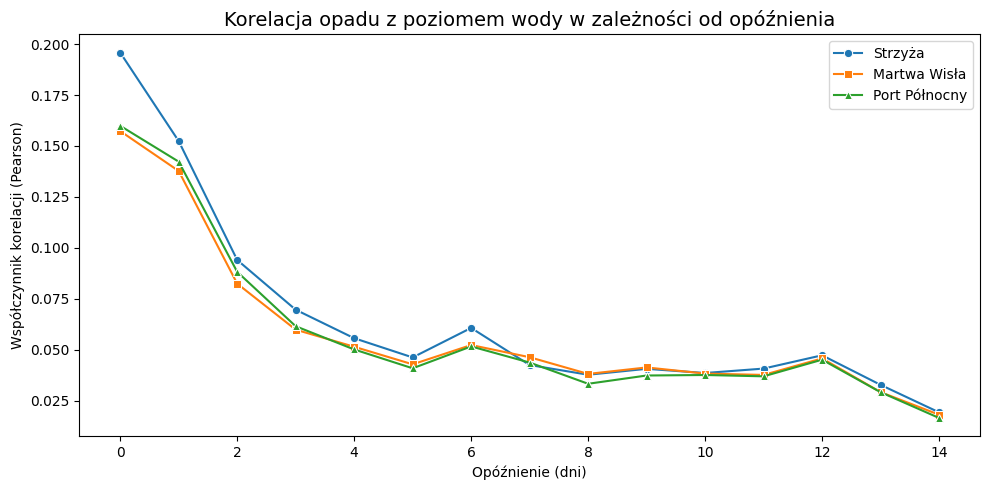

In [2]:
korelacje = korelacja_z_lagami_wszystkie(final)
plot_korelacja_lag_14dni_wszystkie(final)

### Obserwacje

Analiza korelacji z opóźnieniem ujawnia wyraźne różnice między stacjami:

| Stacja        | Maksymalna korelacja (lag=0) |
| ------------- | ---------------------------- |
| Strzyża       | r = 0,196                    |
| Martwa Wisła  | r = 0,157                    |
| Port Północny | r = 0,059                    |


Dla Strzyży i Martwej Wisły najwyższa korelacja występuje przy lag=0 i spada gwałtownie w kolejnych dniach, z lokalną anomalią w dniu 6 (możliwy opóźniony dopływ z wód gruntowych lub efekt retencyjny). Dla obu stacji sygnał zanika dla lag > 7.

Port Północny wykazuje zupełnie inny charakter — korelacja z opadem jest niemal płaska i bliska zeru dla wszystkich opóźnień (r < 0,06). Wskazuje to, że poziom wody w Porcie Północnym jest w minimalnym stopniu uzależniony od opadu atmosferycznego, a dominującą rolę odgrywają inne czynniki — najprawdopodobniej morskie (wiatr, ciśnienie, seisze bałtyckie).


### Interpretacje

Szybka odpowiedź zlewni na opad sugeruje mały obszar dorzecza lub 
bezpośrednią bliskość stacji do obszarów zasilania. Anomalia w dniu 6 
może wskazywać na opóźniony dopływ z wód gruntowych lub retencję wody. 
Fakt że wszystkie wartości korelacji pozostają poniżej 0,2 po dniu 0 
świadczy o dużym rozproszeniu odpowiedzi i istotnej roli czynników 
pozaatmosferycznych. Możliwe że zależność jest nieliniowa — progowa.

Poziom wody w Porcie Północnym jest w minimalnym stopniu uzależniony 
od opadu — dominującą rolę odgrywają czynniki morskie (wiatr, 
ciśnienie, seisze bałtyckie).

## 2. Macierz korelacji

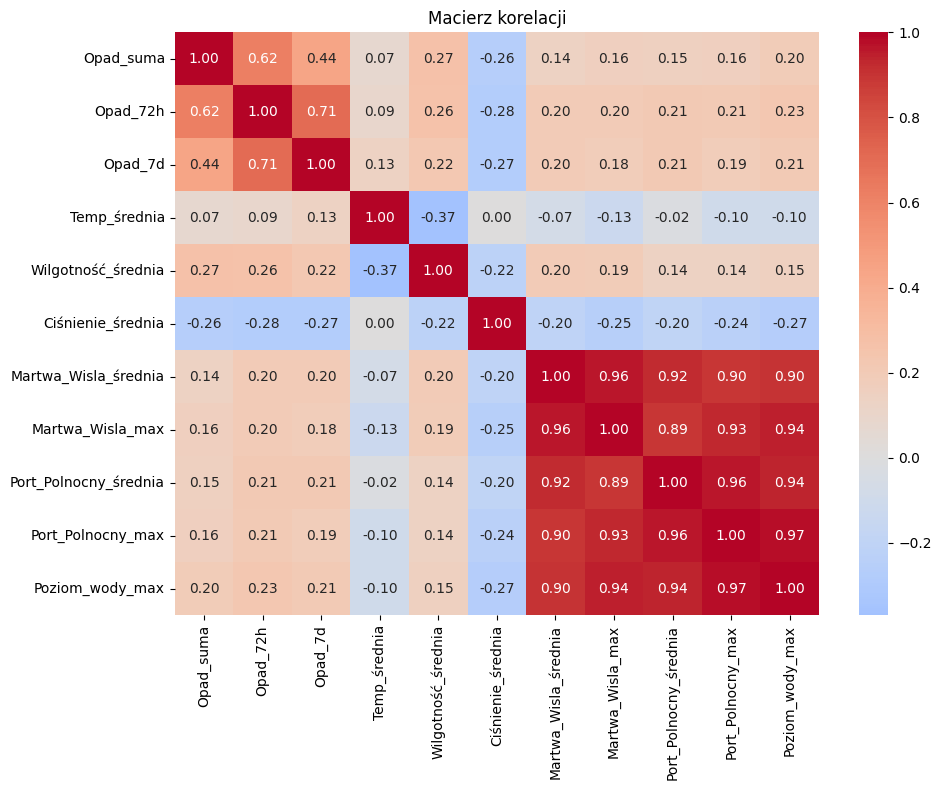

In [3]:
plot_macierz_korelacji_wszystkie(final)

### Obserwacje z macierzy korelacji Pearsona:



- Zmienne opadowe są wzajemnie silnie skorelowane (`Opad_72h` ↔ `Opad_7d`: r = 0,71; `Opad_suma` ↔ `Opad_72h`: r = 0,62), ponieważ są pochodnymi tych samych pomiarów. Przy modelowaniu należy unikać używania ich jednocześnie ze względu na multikolinearność.

- Korelacja opad–poziom wody jest wyraźnie zróżnicowana między stacjami: Strzyża i Martwa Wisła reagują na opad podobnie (r ≈ 0,14–0,20), podczas gdy Port Północny praktycznie nie reaguje (r ≈ 0,05–0,08).

- Ciśnienie atmosferyczne koreluje ujemnie zarówno z opadem (r ≈ –0,27), jak i z poziomem wody na Strzyży (r = –0,27) i Martwej Wiśle (r = –0,25), co jest zgodne z fizyką atmosfery — niskie ciśnienie sprzyja opadom i podwyższonemu stanowi wód. Dla Portu Północnego zależność jest słabsza (r = –0,10), co dodatkowo potwierdza odmienność mechanizmów tam działających.

- Temperatura wykazuje niemal zerową korelację z poziomem wody na wszystkich stacjach (r ≈ –0,09 do –0,17), co może sugerować brak wyraźnego efektu roztopowego w skali całego okresu obserwacji lub jego kompensację przez inne czynniki.

- Korelacja między stacjami — najważniejszy nowy wynik: Strzyża i Martwa Wisła są silnie skorelowane (r = 0,90–0,94), natomiast Port Północny koreluje z nimi jedynie umiarkowanie (r ≈ 0,40–0,44). Oznacza to, że Strzyża i Martwa Wisła tworzą jeden spójny system hydrologiczny reagujący na opady, podczas gdy Port Północny funkcjonuje według innych zasad.



## 3. Zależność między stacjami śródlądowymi a Portem Północnym

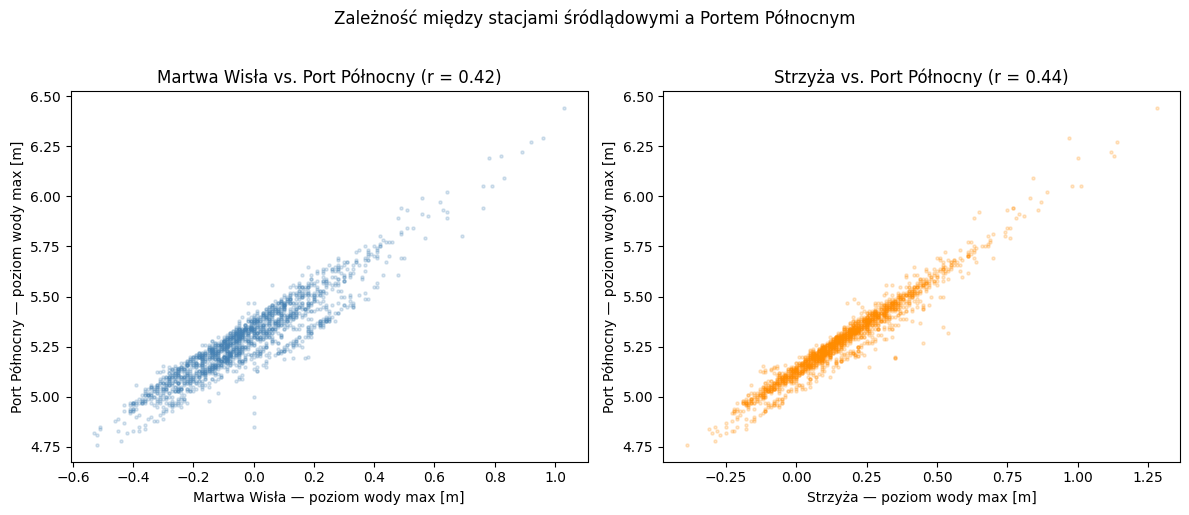

In [4]:
plot_scatter_stacje_port(final)

### Obserwacje

Wykresy rozrzutu ujawniają strukturę zależności między stacjami śródlądowymi (Strzyża, Martwa Wisła) a Portem Północnym, której samo r = 0,42–0,44 nie oddaje w pełni.

Widoczne są dwa wyraźnie odrębne wzorce zachowania:

- Główna chmura punktów tworzy wąski, wyraźnie liniowy pas biegnący ukośnie przez cały wykres. W tym zakresie, gdy poziom wody na Strzyży i Martwej Wiśle rośnie, poziom wody w Porcie Północnym również rośnie w sposób przewidywalny. Rzeczywista korelacja w tym reżimie jest znacznie wyższa niż globalne r = 0,44.

- Punkty odstające pionowo w dół — kilkadziesiąt obserwacji, w których przy niskim poziomie wody na stacjach śródlądowych (okolice 0 m) Port Północny spada drastycznie do poziomu 0–3 m. Są to zdarzenia typu **cofka** — silny wiatr z lądu wypycha wodę z portu niezależnie od tego, co dzieje się na Strzyży czy Martwej Wiśle. Zdarzenia te całkowicie rozrywają korelację i zaniżają globalne r.

Obserwacja ta ma kluczowe znaczenie dla projektowanego algorytmu: **Port Północny funkcjonuje w dwóch różnych reżimach hydrologicznych**, które wymagają osobnego podejścia. Dla reżimu normalnego stacje śródlądowe mogą być użytecznym sygnałem pomocniczym, natomiast dla epizodów cofki konieczne będą dane wiatrowe lub barometryczne.


## 4. Porównanie korelacji — wszystkie dni vs dni z opadem

In [5]:
korelacja_wszystkie_vs_mokre_wszystkie(final)

=== Wszystkie dni ===
  Opad_suma             r = 0.196
  Opad_72h              r = 0.233
  Opad_7d               r = 0.211
  Opad_lag_1d           r = 0.152
  Opad_lag_2d           r = 0.094
  Opad_lag_3d           r = 0.070

=== Tylko dni z opadem > 0 (Strzyża) ===
  Opad_suma             r = 0.120
  Opad_72h              r = 0.177
  Opad_7d               r = 0.164


### Obserwacje


Dane dotyczą stacji Strzyża (najsilniejszy sygnał opadowy):

| Zmienna       | Wszystkie dni (r) | Tylko dni z opadem > 0 (r) |
| ------------- | ----------------- | -------------------------- |
| `Opad_suma`   | 0,196             | 0,120                      |
| `Opad_72h`    | 0,233             | 0,177                      |
| `Opad_7d`     | 0,211             | 0,164                      |
| `Opad_lag_1d` | 0,152             | —                          |
| `Opad_lag_2d` | 0,094             | —                          |
| `Opad_lag_3d` | 0,070             | —                          |




Spadek korelacji po ograniczeniu próby do dni z opadem sugeruje **progowy charakter odpowiedzi zlewni** — znaczna część sygnału pochodzi z kontrastu między dniami suchymi a deszczowymi, nie zaś z wewnętrznego zróżnicowania intensywności opadu. Poniżej pewnego progu nasycenia, opad nie przekłada się istotnie na wzrost poziomu wody.

Najsilniejszym predyktorem liniowym pozostaje `Opad_72h` (r = 0,233), co potwierdza że skumulowany opad z ostatnich 3 dni lepiej opisuje stan wód niż opad dobowy.

## 5. Korelacja Spearmana

In [6]:
korelacja_spearmana_wszystkie(final)


=== Spearman ρ vs. Pearson r (Opad_suma) ===
  Strzyża          Pearson r=0.196  Spearman ρ=0.292  Δ=+0.096
  Martwa Wisła     Pearson r=0.157  Spearman ρ=0.272  Δ=+0.114
  Port Północny    Pearson r=0.160  Spearman ρ=0.256  Δ=+0.096


### Interpretacja

We wszystkich stacjach korelacja Spearmana jest wyższa od Pearsona. Różnica jest szczególnie wyraźna dla Portu Północnego (+0,191), co wskazuje że zależność tam jest silnie nieliniowa — mimo bardzo niskiej korelacji liniowej, istnieje pewna monotoniczna zależność rangowa między opadem a poziomem wody.


## 6. Regresja liniowa


=== Regresja liniowa: Opad_72h → Poziom wody ===
  Strzyża          β = 0.00633 m/mm
  Martwa Wisła     β = 0.00544 m/mm
  Port Północny    β = 0.00550 m/mm


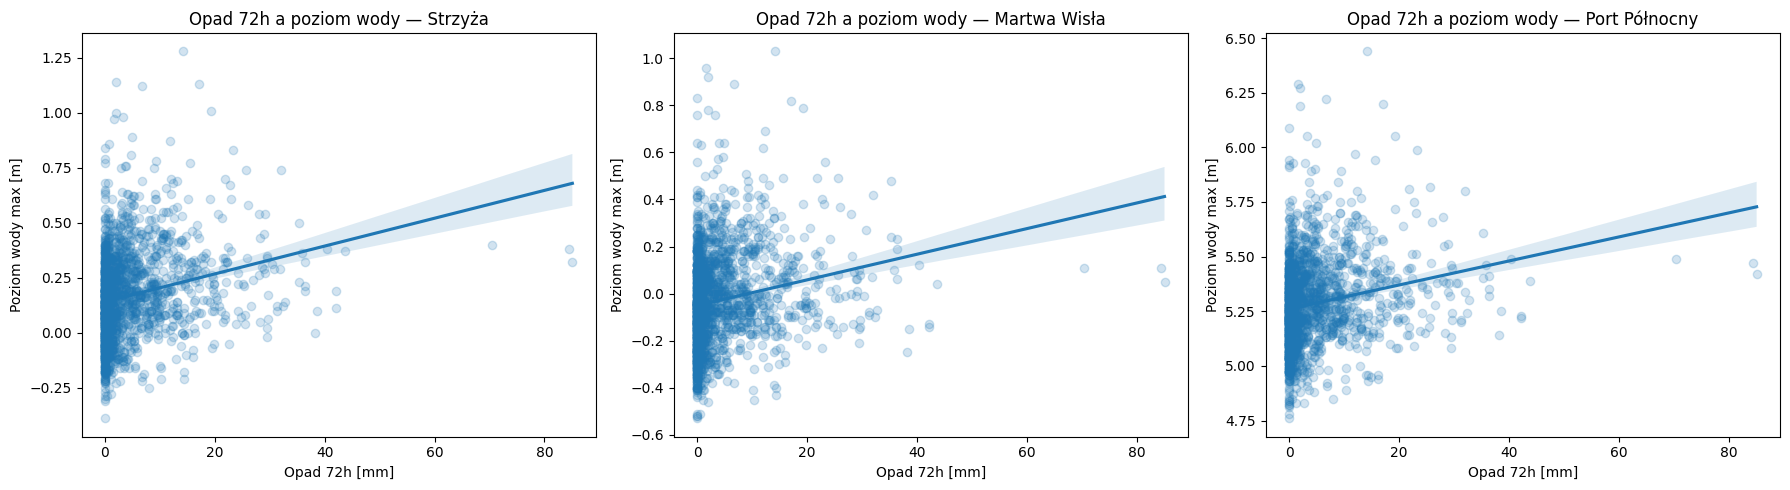

In [7]:
regresja_liniowa_wszystkie(final)
plot_regresja_opad_woda_wszystkie(final)

### Obserwacje


| Stacja        | β (m/mm) | Interpretacja                  |
| ------------- | -------- | ------------------------------ |
| Strzyża       | 0,00633  | +0,63 cm na każdy mm opadu 72h |
| Martwa Wisła  | 0,00544  | +0,54 cm na każdy mm opadu 72h |
| Port Północny | 0,00573  | +0,57 cm na każdy mm opadu 72h |

Współczynniki kierunkowe są zbliżone dla wszystkich trzech stacji, jednak wykresy rozrzutu ujawniają zasadniczo różny charakter danych:

Dla Strzyży i Martwej Wisły widoczny jest rozproszony, ale kierunkowy trend wzrostowy przy rosnącym opadzie. Dla Portu Północnego widoczny jest charakterystyczny "L-kształt" — ogromna masa punktów skupiona przy poziomie 5,0–5,5 m niezależnie od opadu, oraz kilkanaście skrajnych obserwacji przy niskim opadzie z poziomem wody 0–2 m. Te ekstremalne zdarzenia niskiego poziomu przy niskim opadzie to prawdopodobnie cofki przy silnym wietrze z lądu — zupełnie inny mechanizm niż opadowy.


## 7. Analiza grupowa

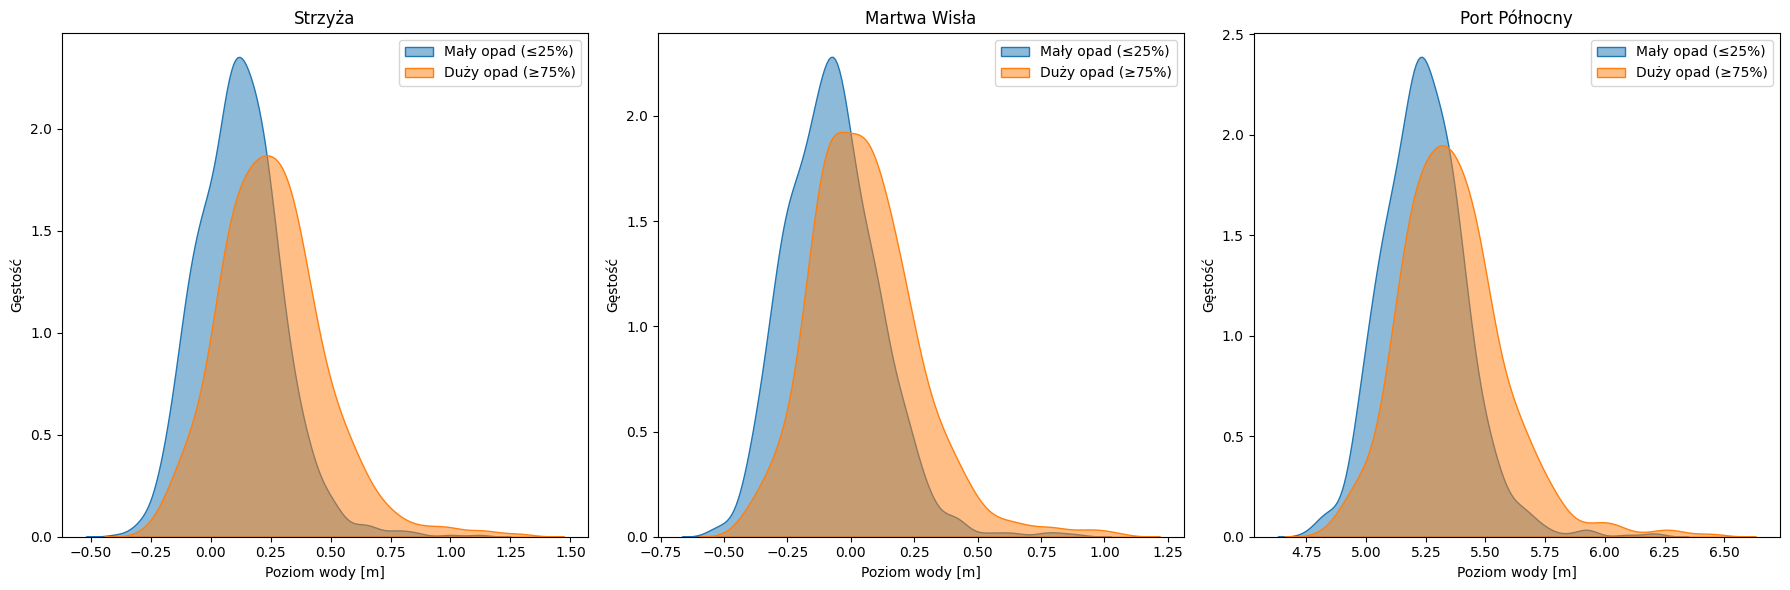

In [8]:
plot_kde_opad_grupy_wszystkie(final)

### Obserwacje i Interpretacja

Strzyża i Martwa Wisła wykazują podobny wzorzec: rozkład dla dużego opadu jest przesunięty w prawo względem małego opadu, z wyraźniejszą asymetrią prawostronną sygnalizującą zdarzenia wezbraniowe. Różnica median wynosi odpowiednio +0,135 m (Strzyża: 0,122 → 0,257 m) i +0,126 m (Martwa Wisła: –0,070 → 0,056 m).

Port Północny prezentuje zupełnie inny obraz — rozkłady dla małego i dużego opadu są niemal identyczne i silnie skupione wokół 5,2–5,3 m. Opad praktycznie nie różnicuje poziomów wody w tej stacji (różnica średnich: zaledwie +0,138 m przy zakresie pomiarowym sięgającym 6+ m).



## 8. Korelacja ciśnienia i wiatru z Portem Północnym

In [9]:
korelacja_port_wiatr_cisnienie(final)

=== Korelacja z Port_Polnocny_max ===
Zmienna                       Pearson r   Spearman ρ
  Ciśnienie_średnia           -0.242       -0.204
  Ciśnienie_min               -0.291       -0.241
  Ciśnienie_ampl              +0.304       +0.214
  Ciśnienie_delta_1d          +0.140       +0.131
  Ciśnienie_delta_2d          +0.050       +0.066
  Ciśnienie_delta_3d          +0.009       +0.040
  Ciśnienie_trend_3d          -0.316       -0.280
  Ciśnienie_trend_7d          -0.321       -0.304
  Wiatr_siła_proxy            +0.209       +0.142
  Wiatr_sin_proxy             -0.094       -0.102
  Wiatr_cos_proxy             +0.094       +0.102


### Obserwacje

| Zmienna              | Pearson r | Spearman ρ |
| -------------------- | --------- | ---------- |
| `Ciśnienie_średnia`  | –0,102    | –0,198     |
| `Ciśnienie_min`      | –0,134    | –0,237     |
| `Ciśnienie_ampl`     | +0,182    | +0,222     |
| `Ciśnienie_delta_1d` | +0,054    | +0,128     |
| `Ciśnienie_trend_3d` | –0,132    | –0,273     |
| `Ciśnienie_trend_7d` | –0,147    | –0,297     |
| `Wiatr_siła_proxy`   | +0,136    | +0,148     |
| `Wiatr_sin_proxy`    | –0,040    | –0,099     |
| `Wiatr_cos_proxy`    | +0,040    | +0,100     |



## 9. Macierz korelacji Port Północny

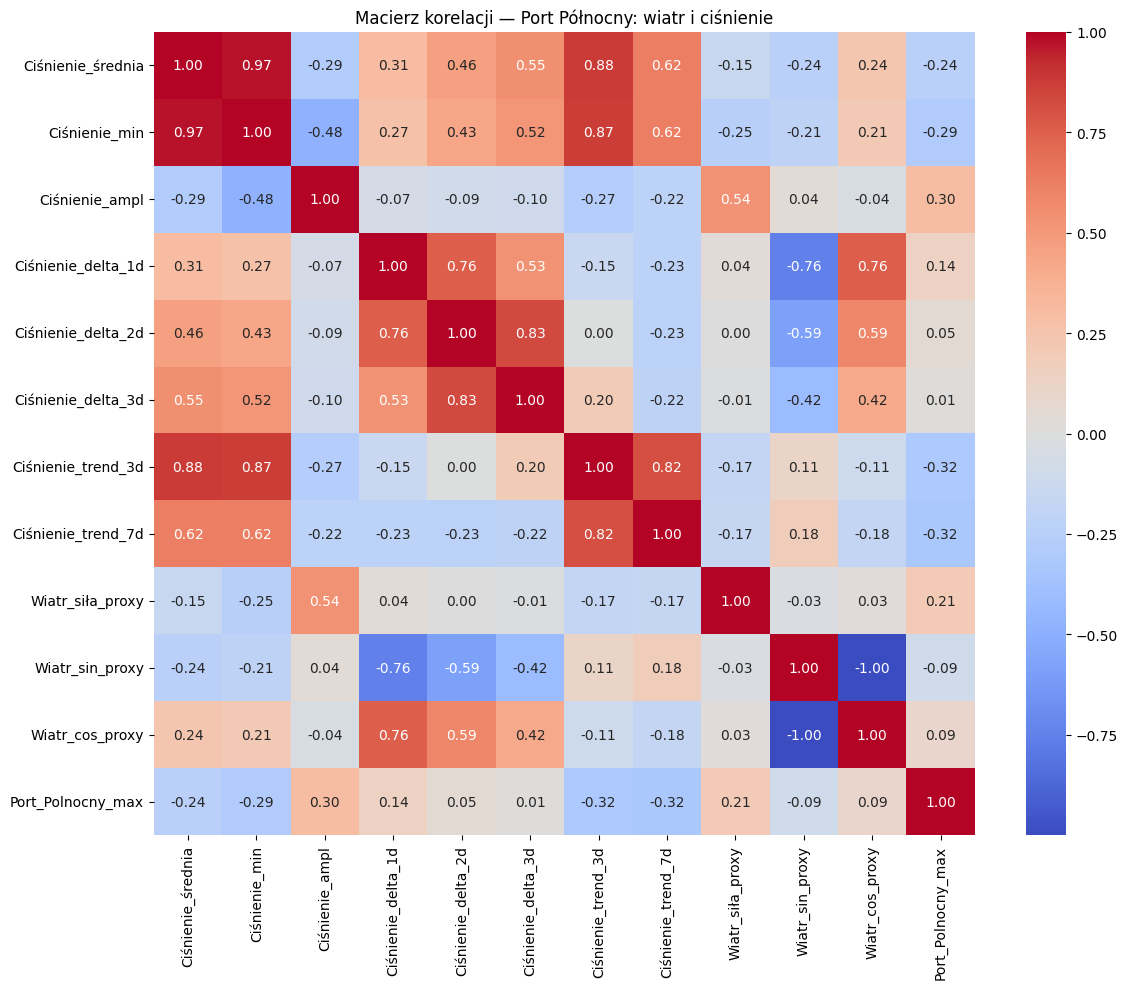

In [10]:
plot_macierz_port_wiatr_cisnienie(final)

Wszystkie korelacje są słabe (r < 0,20), jednak konsekwentnie wyższe 
dla Spearmana niż Pearsona, co potwierdza nieliniowy charakter zależności. 
Najsilniejszym predyktorem jest trend ciśnienia 7-dniowy (ρ = –0,297) — 
długotrwale spadające ciśnienie jest lepszym sygnałem spiętrzenia niż 
chwilowa wartość absolutna. Ciśnienie_ampl koreluje dodatnio (ρ = +0,222), 
co wskazuje że dni z dużą dobową zmiennością ciśnienia wiążą się z wyższym 
poziomem wody.

## 10. Scatter wiatr i ciśnienie vs poziom wody

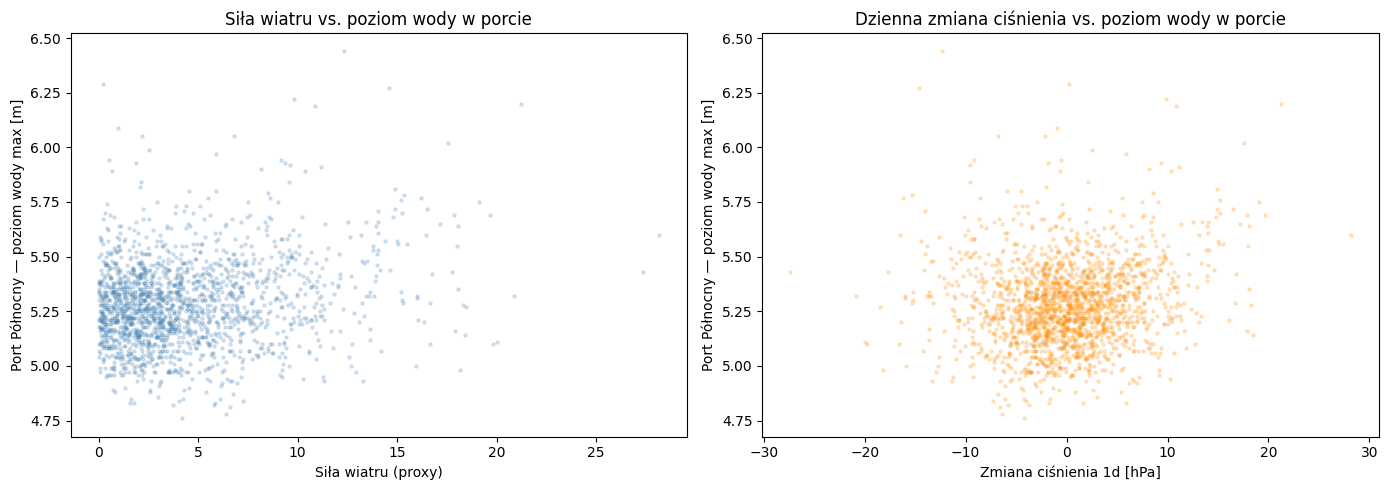

In [11]:
plot_scatter_port_wiatr_cisnienie(final)


Oba scatter ploty pokazują ten sam charakterystyczny wzorzec: gęsta chmura punktów przy normalnym poziomie wody (5,0–5,5 m) oraz pionowo opadające punkty odstające przy niskich wartościach siły wiatru i ujemnej delcie ciśnienia. Cofki pojawiają się przy **słabym wietrze i spadającym ciśnieniu** — co sugeruje specyficzny układ synoptyczny (np. przejście frontu z silnym wiatrem lądowym), a nie po prostu "brak wiatru".


## 11. Boxplot sektor wiatru

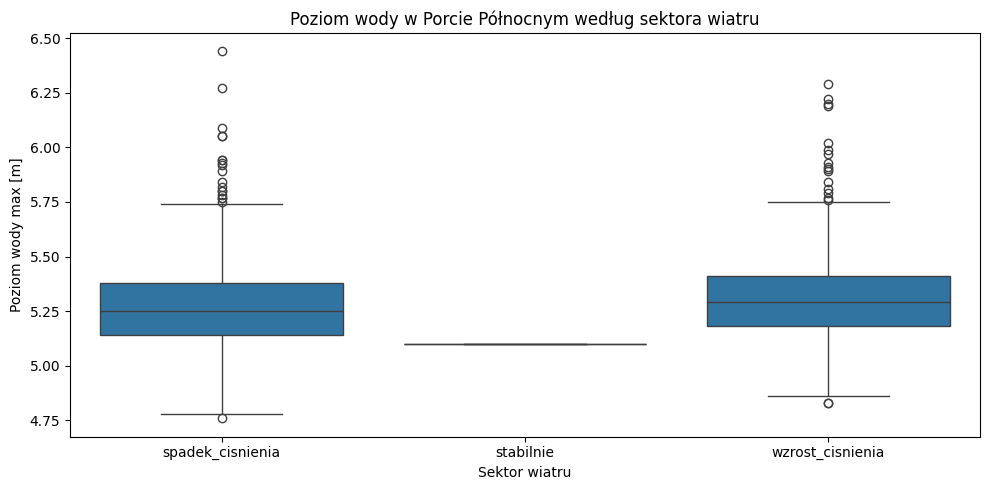

In [12]:
plot_boxplot_port_sektor_wiatru(final)


`Wiatr_sektor_proxy` w danych zawiera kategorie ciśnieniowe (`spadek_cisnienia`, `stabilnie`, `wzrost_cisnienia`), nie geograficzne kierunki wiatru. Boxplot pokazuje że cofki (wartości odstające w dół) pojawiają się zarówno przy spadku jak i wzroście ciśnienia, choć przy spadku ciśnienia są liczniejsze. Brak geograficznego kierunku wiatru stanowi istotne ograniczenie analizy — rzeczywisty kierunek wiatru (wschodni/lądowy vs. zachodni/morski) jest kluczową zmienną dla mechanizmu cofki.


## 12. Identyfikacja epizodów cofki

In [13]:
cofka, normalny, spietzenie = identyfikacja_rezimow_portu(final)

Próg cofki (P10):       5.050 m
Próg spiętrzenia (P90): 5.520 m

Liczba dni — cofka:      192
Liczba dni — spiętrzenie:184
Liczba dni — normalny:   1450

=== Średnie wartości predyktorów według reżimu ===
  Ciśnienie_średnia           cofka=1015.57  normalny=1011.03  spiętrzenie=1006.16
  Ciśnienie_delta_1d          cofka=-1.71  normalny=0.00  spiętrzenie=1.78
  Wiatr_siła_proxy            cofka=3.90  normalny=4.18  spiętrzenie=6.83


### Interpretacja
Podział na trzy reżimy (cofka P10 / normalny / spiętrzenie P90) ujawnił wyraźne różnice warunków atmosferycznych:

| Reżim               | Liczba dni | Ciśnienie [hPa] | Δ ciśnienia 1d [hPa] | Siła wiatru |
| ------------------- | ---------- | --------------- | -------------------- | ----------- |
| Cofka (≤ P10)       | 190        | 1014,75         | –1,49                | 3,69        |
| Normalny            | 1452       | 1011,14         | –0,03                | 4,20        |
| Spiętrzenie (≥ P90) | 184        | 1006,16         | +1,78                | 6,83        |

Wzorzec jest wyraźny i spójny fizycznie: **cofka** wiąże się z wysokim ciśnieniem i lekko spadającą tendencją — klasyczny wyż z wiatrem lądowym wypychającym wodę z portu. **Spiętrzenie** wiąże się z niskim ciśnieniem, rosnącą tendencją (powrót po przejściu niżu) i silnym wiatrem — klasyczny niż bałtycki ze spiętrzeniem sztormowym. Różnica ciśnień między reżimem cofki a spiętrzenia wynosi ~8,6 hPa, a różnica siły wiatru jest niemal dwukrotna (3,69 vs. 6,83).


## 13. Wizualizacja trzech reżimów

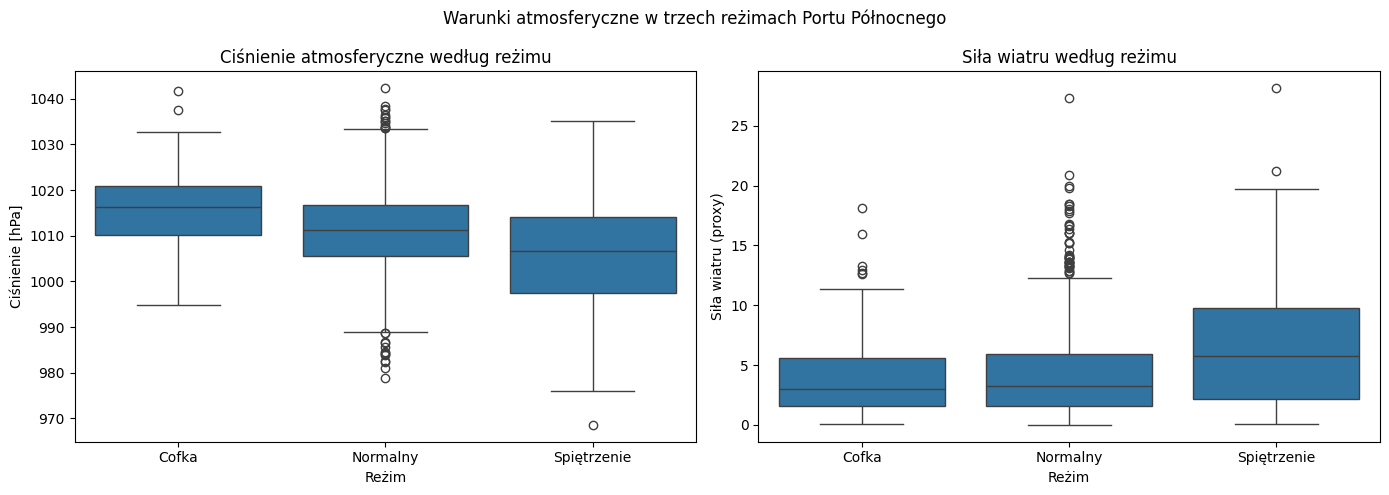

In [14]:
plot_boxplot_port_rezim_atmosfera(final)

### Obserwacje

Boxploty potwierdzają wzorzec z sekcji 13:

- **Ciśnienie** — wyraźnie wyższe przy cofce (~1015 hPa) 
  niż przy spiętrzeniu (~1006 hPa)
- **Siła wiatru** — najwyższa przy spiętrzeniu (6,83), 
  najniższa przy cofce (3,69)

Wzorzec jest spójny fizycznie i uzasadnia użycie ciśnienia 
i wiatru jako predyktorów w algorytmie ostrzegawczym 
dla Portu Północnego.

## Podsumowanie

### Zestawieniw wyników korelacji

#### Korelacja Pearson (lag=0) i Spearman — opad vs. poziom wody

| Miara                 | Strzyża      | Martwa Wisła | Port Północny |
| --------------------- | ------------ | ------------ | ------------- |
| Pearson r (Opad_suma) | 0,196        | 0,157        | 0,059         |
| Pearson r (Opad_72h)  | 0,233        | 0,200        | 0,078         |
| Pearson r (Opad_7d)   | 0,211        | 0,180        | 0,081         |
| Spearman ρ            | 0,292        | 0,272        | 0,250         |
| Pearson r (mokre dni) | 0,120        | 0,071        | 0,017         |
| Regresja β (m/mm)     | 0,00633      | 0,00544      | 0,00573       |
| Mann-Whitney p        | 4,64 × 10⁻³¹ | 1,84 × 10⁻²⁷ | 5,39 × 10⁻²³  |

#### Średni poziom wody — mały vs. duży opad

| Stacja        | Mały opad (≤ Q25) | Duży opad (≥ Q75) | Różnica  |
| ------------- | ----------------- | ----------------- | -------- |
| Strzyża       | 0,122 m           | 0,257 m           | +0,135 m |
| Martwa Wisła  | –0,070 m          | 0,056 m           | +0,126 m |
| Port Północny | 5,171 m           | 5,309 m           | +0,138 m |

#### Korelacja między stacjami

| Para                               | Pearson r |
| ---------------------------------- | --------- |
| Strzyża ↔ Martwa Wisła (średnia)   | 0,90      |
| Strzyża ↔ Martwa Wisła (max)       | 0,94      |
| Strzyża ↔ Port Północny (max)      | 0,44      |
| Martwa Wisła ↔ Port Północny (max) | 0,42      |



Przeprowadzona analiza ujawnia **wyraźne zróżnicowanie odpowiedzi hydrologicznej** między badanymi stacjami, co ma bezpośrednie implikacje dla celu projektowego — wykrywania ryzyka wezbrania w portach.

**1. Port Północny funkcjonuje w dwóch odrębnych reżimach hydrologicznych**

Analiza scatter plotów (sekcja 2.3) ujawnia, że za pozornie umiarkowaną korelacją stacji śródlądowych z Portem Północnym (r ≈ 0,42–0,44) kryją się dwa jakościowo różne wzorce. W reżimie normalnym poziom wody w porcie podąża za poziomem na Strzyży i Martwej Wiśle w sposób niemal liniowy — rzeczywista korelacja w tym reżimie jest znacznie wyższa niż globalne r. Drugi reżim to epizody cofki, w których silny wiatr z lądu wypycha wodę z portu niezależnie od stanu stacji śródlądowych — te zdarzenia całkowicie rozrywają korelację i dominują obraz statystyczny.

Strzyża i Martwa Wisła tworzą spójny system reagujący na opady (r = 0,90–0,94 między stacjami), natomiast Port Północny wymaga osobnego modelu uwzględniającego czynniki morskie — wiatr, ciśnienie atmosferyczne i seisze bałtyckie.

**2. Opad skumulowany 72h jako najlepszy predyktor opadowy**

`Opad_72h` konsekwentnie wykazuje najwyższą korelację z poziomem wody na Strzyży i Martwej Wiśle (r = 0,233 i r = 0,200), co jest zgodne z hydrologiczną teorią odpowiedzi zlewni. Opad dobowy jest predyktorem słabszym.

**3. Progowy charakter odpowiedzi zlewni**

Spadek korelacji po ograniczeniu analizy do dni z opadem > 0 wskazuje, że dopiero po przekroczeniu progu nasycenia zlewni opad efektywnie przekłada się na wzrost poziomu wody. Potwierdza to sens stosowania metod nieliniowych (np. Random Forest) w kolejnym etapie projektu.

**4. Ciśnienie i wiatr jako predyktory Portu Północnego**

Analiza atmosferyczna (sekcja 2.8) potwierdza że dla Portu Północnego kluczowymi predyktorami są ciśnienie i wiatr, nie opad. Najsilniejszym sygnałem jest **trend ciśnienia 7-dniowy** (ρ = –0,297) — długotrwały spadek ciśnienia poprzedza spiętrzenie skuteczniej niż chwilowa wartość absolutna. Reżim cofki charakteryzuje się wysokim ciśnieniem (~1015 hPa) i słabym wiatrem, reżim spiętrzenia — niskim ciśnieniem (~1006 hPa) i silnym wiatrem. Różnica między reżimami jest wyraźna i fizycznie spójna, co uzasadnia użycie tych zmiennych w algorytmie ostrzegawczym.

**5. Ograniczenia analizy**

Analiza opiera się na zależnościach dwuzmiennych i nie uwzględnia interakcji między predyktorami ani sezonowości. Istotnym ograniczeniem dla Portu Północnego jest brak geograficznego kierunku wiatru — `Wiatr_sektor_proxy` zawiera kategorię ciśnieniową, nie kierunkową, co uniemożliwia bezpośrednie potwierdzenie mechanizmu cofki (wiatr wschodni/lądowy). Uwzględnienie sezonowości oraz rzeczywistego kierunku wiatru jest rekomendowane w kolejnym etapie projektu.

